# Mode order and sampling

**Scientific question.** How does ideal Zernike correction reduce absolute
wavefront RMS and the fraction of variance remaining as more modes are
removed? At fixed pupil and outer scale, changing `r0` rescales the wavefront
amplitude; this study checks that it does not change the fractional reduction
for the same realizations.

The atmosphere and modal basis use installed `shwfs_ao` APIs. This is an ideal
projection study, not a sensor or deformable-mirror performance model.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shwfs_ao.backends.native.atmosphere import (
    FrozenFlowAtmosphere,
    FrozenFlowAtmosphereConfig,
    SPECTRUM_SUBHARMONIC_V2,
    TRANSLATION_FOURIER_SUBPIXEL_V2,
)
from shwfs_ao.backends.native.modes import (
    generate_zernike_modes,
    polar_pupil_coordinates,
)
from shwfs_ao.core.geometry import build_pupil_geometry
from shwfs_ao.core.wavefront import masked_rms

In [2]:
# Fast-smoke contract (AO-REF-019): fast CI injects `FAST_SMOKE = True`
# right after this tagged cell; the committed outputs below are always
# the full study (FAST_SMOKE = False), executed by the scheduled lane.
FAST_SMOKE = False

In [3]:
SEED = 20240517
TELESCOPE_DIAMETER_M = 2.0
PUPIL_PIXELS = 96
MODE_COUNTS = (3, 10, 21) if FAST_SMOKE else (3, 6, 10, 15, 21, 28, 36)
FRIED_PARAMETERS_M = (0.5, 0.3, 0.2)
N_REALIZATIONS = 2 if FAST_SMOKE else 6

## Configuration

In [4]:
pupil = build_pupil_geometry(
    telescope_diameter_m=TELESCOPE_DIAMETER_M,
    pupil_shape=(PUPIL_PIXELS, PUPIL_PIXELS),
)
rho, theta = polar_pupil_coordinates(pupil.x_m, pupil.y_m, TELESCOPE_DIAMETER_M)
modes = generate_zernike_modes(rho, theta, pupil.pupil_mask, max_radial_order=8)
mode_matrix = np.stack(
    [np.where(pupil.pupil_mask, mode, 0.0)[pupil.pupil_mask] for mode in modes.values()],
    axis=1,
)
# Remove the sampled-pupil mean before comparing nested modal subspaces.
mode_matrix -= mode_matrix.mean(axis=0, keepdims=True)
projectors = {n: np.linalg.qr(mode_matrix[:, :n])[0] for n in MODE_COUNTS}
print(f"{mode_matrix.shape[1]} Zernike modes available (piston excluded)")

44 Zernike modes available (piston excluded)


## Simulation call

In [5]:
def mode_statistics(r0_m):
    input_variances = []
    residual_variances = []
    for realization in range(N_REALIZATIONS):
        atmosphere = FrozenFlowAtmosphere(
            FrozenFlowAtmosphereConfig(
                grid_size=PUPIL_PIXELS,
                screen_grid_size=3 * PUPIL_PIXELS,
                spectrum_model=SPECTRUM_SUBHARMONIC_V2,
                translation_model=TRANSLATION_FOURIER_SUBPIXEL_V2,
                normalize_rms=False,
                delta_m=pupil.pixel_spacing_xy_m[0],
                pupil_diameter_m=TELESCOPE_DIAMETER_M,
                r0_m=r0_m,
                outer_scale_m=25.0,
                wind_m_per_s=(8.0, 0.0),
                root_seed=SEED + realization,
            ),
            pupil_mask=pupil.pupil_mask,
        )
        atmosphere.reset(realization_index=realization)
        sampled = atmosphere.opd_at(0.0)[pupil.pupil_mask]
        input_variances.append(np.mean(sampled**2))
        residual_variances.append([
            np.mean((sampled - q @ (q.T @ sampled))**2)
            for q in projectors.values()
        ])
    input_variances = np.asarray(input_variances)
    residual_variances = np.asarray(residual_variances)
    variance_fraction = residual_variances.mean(axis=0) / input_variances.mean()
    mean_individual_rms_fraction = np.sqrt(
        residual_variances / input_variances[:, None]
    ).mean(axis=0)
    return {
        "input_rms_m": np.sqrt(input_variances.mean()),
        "residual_rms_m": np.sqrt(residual_variances.mean(axis=0)),
        "variance_fraction": variance_fraction,
        "rms_fraction": np.sqrt(variance_fraction),
        "mean_individual_rms_fraction": mean_individual_rms_fraction,
    }

statistics = [mode_statistics(r0) for r0 in FRIED_PARAMETERS_M]
grid = np.stack([row["rms_fraction"] for row in statistics])
absolute_rms_nm = np.stack([row["residual_rms_m"] * 1e9 for row in statistics])

# Same seeds and fixed L0: r0 changes amplitude, not fractional projection error.
np.testing.assert_allclose(grid, np.broadcast_to(grid[0], grid.shape), rtol=1e-11, atol=1e-12)
for i, r0 in enumerate(FRIED_PARAMETERS_M):
    np.testing.assert_allclose(
        absolute_rms_nm[i] / absolute_rms_nm[0],
        (FRIED_PARAMETERS_M[0] / r0)**(5 / 6), rtol=1e-11,
    )
assert np.all(np.diff(grid, axis=1) <= 1e-12)
assert np.all((grid >= 0) & (grid <= 1 + 1e-12))


## Diagnostic table

In [6]:
table = pd.DataFrame([
    {
        "r0 (m)": r0,
        "D/r0": TELESCOPE_DIAMETER_M / r0,
        "modes corrected": n,
        "input sqrt(mean variance) (nm)": row["input_rms_m"] * 1e9,
        "residual sqrt(mean variance) (nm)": row["residual_rms_m"][j] * 1e9,
        "mean residual variance / mean input variance": row["variance_fraction"][j],
        "sqrt(mean residual variance / mean input variance)": row["rms_fraction"][j],
        "mean individual RMS fraction": row["mean_individual_rms_fraction"][j],
    }
    for r0, row in zip(FRIED_PARAMETERS_M, statistics)
    for j, n in enumerate(MODE_COUNTS)
])
table


,r0 (m),D/r0,modes corrected,input sqrt(mean variance) (nm),residual sqrt(mean variance) (nm),mean residual variance / mean input variance,sqrt(mean residual variance / mean input variance),mean individual RMS fraction
0,0.5,4.000000,3,193.232591,67.001760,0.120230,0.346742,0.375899
1,0.5,4.000000,6,193.232591,59.032389,0.093330,0.305499,0.332175
2,0.5,4.000000,10,193.232591,44.232645,0.052399,0.228909,0.246580
3,0.5,4.000000,15,193.232591,39.337236,0.041443,0.203575,0.221583
4,0.5,4.000000,21,193.232591,33.333369,0.029758,0.172504,0.189469
5,0.5,4.000000,28,193.232591,29.867327,0.023891,0.154567,0.168865
6,0.5,4.000000,36,193.232591,26.311705,0.018541,0.136166,0.148911
7,0.3,6.666667,3,295.770145,102.555786,0.120230,0.346742,0.375899
8,0.3,6.666667,6,295.770145,90.357523,0.093330,0.305499,0.332175
9,0.3,6.666667,10,295.770145,67.704396,0.052399,0.228909,0.246580


## Plot

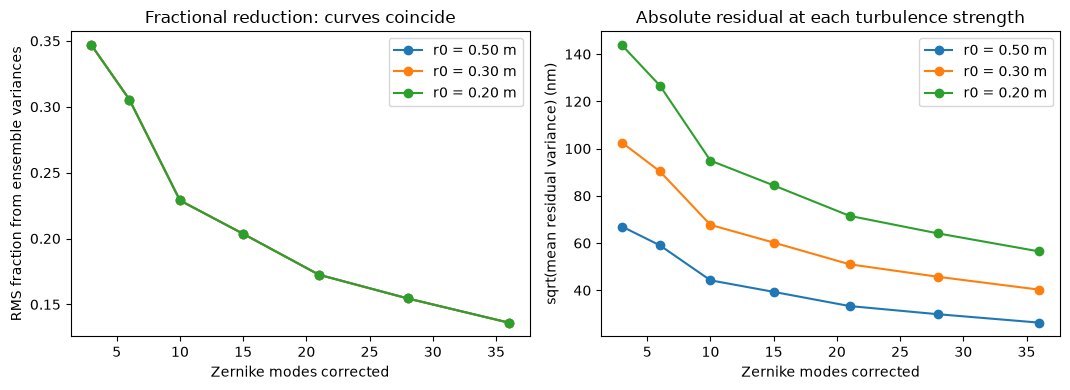

In [7]:
figure, (left, right) = plt.subplots(1, 2, figsize=(10.8, 4.0))
for i, r0 in enumerate(FRIED_PARAMETERS_M):
    left.plot(MODE_COUNTS, grid[i], "o-", label=f"r0 = {r0:.2f} m")
    right.plot(MODE_COUNTS, absolute_rms_nm[i], "o-", label=f"r0 = {r0:.2f} m")
left.set_xlabel("Zernike modes corrected")
left.set_ylabel("RMS fraction from ensemble variances")
left.set_title("Fractional reduction: curves coincide")
left.legend()
right.set_xlabel("Zernike modes corrected")
right.set_ylabel("sqrt(mean residual variance) (nm)")
right.set_title("Absolute residual at each turbulence strength")
right.legend()
figure.tight_layout()
plt.show()


## Interpretation

Adding modes to a nested least-squares basis cannot increase projection error.
The fractional curves coincide across `r0`: with fixed `D`, `L0`, and random
phases, OPD scales as `r0**(-5/6)`, and the scale cancels from the fraction.
Stronger turbulence therefore needs more modes to reach a fixed **absolute
RMS target**, not a fixed fractional reduction.

The main plotted fraction is `sqrt(mean residual variance / mean input
variance)`. The table also reports `mean(sqrt(residual variance / input
variance))`; these ensemble statistics need not agree. No realization is
rescaled to a target RMS. Six full-study realizations are not a precise
calibration against an infinite-outer-scale Noll coefficient, especially with
finite `L0 = 25 m` and finite spatial bandwidth.

## Limitations

- Ideal projection excludes sensor sampling, reconstruction errors, detector
  noise, control delay, and the realizable mirror basis. It cannot by itself
  specify a sufficient lenslet count.
- The short ensemble has sampling uncertainty, particularly in low-order
  power. The assertions test exact scaling and nested projection relations,
  not an unsupported match to a theoretical coefficient.
- A different outer scale changes the distribution of modal power and the
  fractional curves.
